# Global Equity Multi-Factor Screening
**Universe:** Samsung Electronics · SK Hynix · TSMC · Toyota · Alibaba  
**Period:** 2-Year Historical Data  
**Factors:**
| Factor | Weight | Direction | Rationale |
|---|---|---|---|
| 12-Month Momentum | 50% | Higher → Better | Price trend continuation |
| P/B Ratio (PBR) | 50% | Lower → Better | Value (asset discount) |

> **Scoring method:** Each factor is z-score normalized. PBR is negated before weighting so that a lower P/B always contributes a higher composite score. Final composite = 0.5 × Momentum_Z + 0.5 × (−PBR_Z).

## Multi-Factor Screening — 아시아 주요 5개 종목 분석

### 분석 목적
단순 주가 상승률(모멘텀)만으로 종목을 선별할 경우,
현재 주가가 고평가된 종목을 과대평가할 위험이 있다.
이를 보완하기 위해 모멘텀(50%)과 PBR(50%)을 결합한
Multi-factor 방식으로 아시아 주요 5개 종목의 투자 매력도를 평가한다.

- 분석 대상: SK하이닉스, 삼성전자, TSMC, 도요타, 알리바바
- 분석 기간: 2025.03 ~ 2026.03 (12개월)
- 사용 팩터: 모멘텀(12개월 수익률) 50% + PBR(주가순자산비율) 50%

In [ ]:
# ── 0. Install dependencies (first run only) ────────────────────────────
# !pip install yfinance pandas matplotlib seaborn scipy

In [5]:
# ── 1. Imports & global settings ───────────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# ── Shared color palette (consistent across all charts) ─────────────────
COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
C_POS, C_NEG = '#2ca02c', '#d62728'   # green / red

print(f'pandas {pd.__version__} | yfinance {yf.__version__}')

pandas 3.0.1 | yfinance 1.2.0


In [6]:
# ── 2. Universe & date range ────────────────────────────────────────────
TICKERS = {
    'Samsung Electronics': '005930.KS',
    'SK Hynix':            '000660.KS',
    'TSMC':                'TSM',
    'Toyota':              'TM',
    'Alibaba':             'BABA',
}
NAMES  = list(TICKERS.keys())
SYMS   = list(TICKERS.values())

END   = datetime.today()
START = END - timedelta(days=365 * 2 + 10)

LOOKBACK = 252        # ≈ 12 months in trading days
W_MOM    = 0.50       # momentum weight
W_PBR    = 0.50       # PBR weight

print(f'Date range : {START.date()} → {END.date()}')
print(f'Weights    : Momentum {W_MOM:.0%}  |  PBR {W_PBR:.0%}')

Date range : 2024-03-05 → 2026-03-15
Weights    : Momentum 50%  |  PBR 50%


In [7]:
# ── 3. Download adjusted close prices ──────────────────────────────────
raw = yf.download(
    tickers=SYMS,
    start=START,
    end=END,
    auto_adjust=True,
    progress=True,
)

close = raw['Close'].copy()
close.rename(columns={v: k for k, v in TICKERS.items()}, inplace=True)
close = close[NAMES]
close_filled = close.ffill()

print(f'\nDownloaded  : {len(close)} trading days')
print(f'Missing (after ffill): {close_filled.isnull().sum().sum()}')
close_filled.tail(3)

[*********************100%***********************]  5 of 5 completed


Downloaded  : 524 trading days
Missing (after ffill): 3


Ticker,Samsung Electronics,SK Hynix,TSMC,Toyota,Alibaba
Date,,,,,
2026-03-11,190000.0,955000.0,354.559998,220.770004,136.289993
2026-03-12,187900.0,930000.0,336.709991,216.589996,134.199997
2026-03-13,183500.0,910000.0,338.309998,210.839996,135.210007


In [8]:
# ── 4. Fetch PBR (Price-to-Book Ratio) from yfinance .info ─────────────
# yfinance returns the latest trailing P/B from the exchange info endpoint.
# If a ticker returns None, a fallback NaN is used and flagged.

pbr_raw = {}
for name, sym in TICKERS.items():
    try:
        info = yf.Ticker(sym).info
        pbr  = info.get('priceToBook', np.nan)
        pbr_raw[name] = pbr
        print(f'  {name:<24} P/B = {pbr}')
    except Exception as e:
        pbr_raw[name] = np.nan
        print(f'  {name:<24} ERROR: {e}')

pbr = pd.Series(pbr_raw, name='P/B Ratio')

# ── Sanity check ────────────────────────────────────────────────────────
if pbr.isnull().any():
    missing_names = pbr[pbr.isnull()].index.tolist()
    print(f'\n⚠️  P/B data missing for: {missing_names}')
    print('   → Filling with universe median as fallback.')
    pbr.fillna(pbr.median(), inplace=True)

print(f'\nP/B Ratio summary:\n{pbr.describe().round(2)}')

  Samsung Electronics      P/B = nan
  SK Hynix                 P/B = nan
  TSMC                     P/B = 51.68091
  Toyota                   P/B = 11.26298
  Alibaba                  P/B = 2.094539

⚠️  P/B data missing for: ['Samsung Electronics', 'SK Hynix']
   → Filling with universe median as fallback.

P/B Ratio summary:
count     5.00
mean     17.51
std      19.51
min       2.09
25%      11.26
50%      11.26
75%      11.26
max      51.68
Name: P/B Ratio, dtype: float64


In [9]:
# ── 5. Compute 12-month momentum ───────────────────────────────────────
latest_price = close_filled.iloc[-1]
price_1y_ago = close_filled.iloc[-1 - LOOKBACK]
momentum     = (latest_price / price_1y_ago - 1) * 100
momentum.name = '12M Momentum (%)'

print(f'As-of date  : {close_filled.index[-1].date()}')
print(f'Compare date: {close_filled.index[-1 - LOOKBACK].date()}\n')
print(momentum.round(2))

As-of date  : 2026-03-13
Compare date: 2025-03-21

Ticker
Samsung Electronics    203.82
SK Hynix               324.73
TSMC                    93.25
Toyota                  12.74
Alibaba                  1.74
Name: 12M Momentum (%), dtype: float64


In [10]:
# ── 6. Multi-Factor Scoring ─────────────────────────────────────────────
#
#  Step 1 — Z-score normalize each raw factor across the universe
#            z = (x - mean) / std
#
#  Step 2 — Invert PBR z-score  (lower PBR → higher score)
#            pbr_z_inv = -pbr_z
#
#  Step 3 — Weighted composite
#            composite = W_MOM * mom_z  +  W_PBR * pbr_z_inv
#
#  Step 4 — Rank: higher composite → better rank (rank 1 = best)

def zscore(s: pd.Series) -> pd.Series:
    """Cross-sectional z-score (mean=0, std=1)."""
    return (s - s.mean()) / s.std(ddof=0)

mom_z      = zscore(momentum)          # higher momentum → higher z
pbr_z_inv  = -zscore(pbr)             # lower PBR → higher (inverted) z
composite  = W_MOM * mom_z + W_PBR * pbr_z_inv

# Individual factor ranks (1 = best within that factor)
mom_rank   = momentum.rank(ascending=False).astype(int)
pbr_rank   = pbr.rank(ascending=True).astype(int)      # lower PBR = rank 1
final_rank = composite.rank(ascending=False).astype(int)

# ── Master results table ────────────────────────────────────────────────
results = pd.DataFrame({
    '12M Momentum (%)':  momentum.round(2),
    'Momentum Rank':     mom_rank,
    'P/B Ratio':         pbr.round(2),
    'PBR Rank':          pbr_rank,
    'Momentum Z':        mom_z.round(3),
    'PBR Z (inv)':       pbr_z_inv.round(3),
    'Composite Score':   composite.round(3),
    'Final Rank':        final_rank,
}).sort_values('Final Rank')

print('\n── Multi-Factor Screening Results ──────────────────────────')
results


── Multi-Factor Screening Results ──────────────────────────


,12M Momentum (%),Momentum Rank,P/B Ratio,PBR Rank,Momentum Z,PBR Z (inv),Composite Score,Final Rank
SK Hynix,324.73,1,11.26,3,1.614,0.358,0.986,1
Samsung Electronics,203.82,2,11.26,3,0.626,0.358,0.492,2
Alibaba,1.74,5,2.09,1,-1.026,0.884,-0.071,3
Toyota,12.74,4,11.26,3,-0.936,0.358,-0.289,4
TSMC,93.25,3,51.68,5,-0.278,-1.958,-1.118,5


## 결과 해석

### 모멘텀 단일 순위 → 최종 종합 순위 변화

모멘텀 단일 팩터에서는 SK하이닉스가 1위였다.
PBR 팩터를 추가하자 알리바바와 TSMC의 순위가 변했다.

알리바바는 주가 상승률은 낮았으나 저평가된 종목이라
종합순위가 상승했고, TSMC는 반대로 주가 상승률은
높았으나 그만큼 고평가된 종목이라 순위가 하락했다.

이처럼 모멘텀 단일 팩터만으로는 단순 주가 상승률만
확인 가능했으나, PBR을 추가함으로써 현재 주가의
고/저평가 여부까지 반영한 종목 선별이 가능해졌다.

### 주목할 종목
- **SK하이닉스 (+324.73%)**: AI 반도체 수요 급증으로 
  모멘텀과 밸류에이션 모두 1위. 종합점수 압도적 선두.
- **알리바바 (+1.74%)**: 모멘텀 꼴찌였으나 낮은 PBR로 
  3위로 반등. 저평가 매력 존재.
- **TSMC**: 모멘텀 3위였으나 높은 PBR로 최종 꼴찌. 
  가격 부담이 투자 매력을 상쇄.

In [11]:
# ── 7. Rank Comparison Table ────────────────────────────────────────────
# Shows how each stock's rank changed when PBR was added to the model

rank_cmp = pd.DataFrame({
    'Momentum Rank':    mom_rank,
    'PBR Rank':         pbr_rank,
    'Final Rank':       final_rank,
    'Rank Shift':       mom_rank - final_rank,   # +n = improved, -n = dropped
}).sort_values('Final Rank')

def style_shift(val):
    """Color-code rank shifts: green = improved, red = dropped."""
    if val > 0:
        return 'color: #2ca02c; font-weight: bold'
    elif val < 0:
        return 'color: #d62728; font-weight: bold'
    return 'color: grey'

display(
    rank_cmp.style
        .map(style_shift, subset=['Rank Shift'])
        .format({'Rank Shift': lambda x: f'+{x}' if x > 0 else str(x)})
        .set_caption('Rank Comparison: Momentum-only vs Multi-Factor (Momentum + PBR)')
        .set_table_styles([{
            'selector': 'caption',
            'props': [('font-size', '13px'), ('font-weight', 'bold'), ('padding', '8px 0')]
        }])
)

,Momentum Rank,PBR Rank,Final Rank,Rank Shift
SK Hynix,1,3,1,0
Samsung Electronics,2,3,2,0
Alibaba,5,1,3,+2
Toyota,4,3,4,0
TSMC,3,5,5,-2


---
## 📊 Visualizations

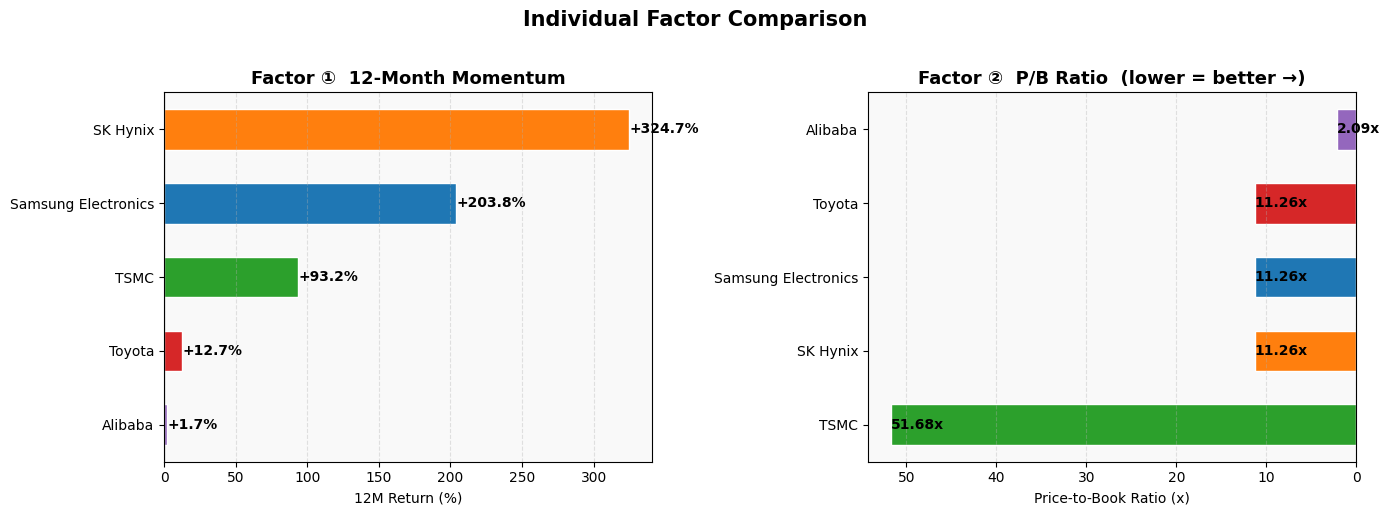

Saved: factor_comparison.png


In [12]:
# ── 8. Factor Overview: Momentum vs PBR side-by-side ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ─ Left: Momentum bar
ax_m = axes[0]
sr_m = results.sort_values('12M Momentum (%)')
cols_m = [COLORS[NAMES.index(n)] for n in sr_m.index]
bars_m = ax_m.barh(sr_m.index, sr_m['12M Momentum (%)'],
                   color=cols_m, edgecolor='white', height=0.55)
for bar, val in zip(bars_m, sr_m['12M Momentum (%)']):
    off = 0.4 if val >= 0 else -0.4
    ha  = 'left' if val >= 0 else 'right'
    ax_m.text(val + off, bar.get_y() + bar.get_height() / 2,
              f'{val:+.1f}%', va='center', ha=ha, fontsize=10, fontweight='bold')
ax_m.axvline(0, color='black', lw=0.8)
ax_m.set_title('Factor ①  12-Month Momentum', fontsize=13, fontweight='bold')
ax_m.set_xlabel('12M Return (%)')
ax_m.grid(axis='x', linestyle='--', alpha=0.35)
ax_m.set_facecolor('#f9f9f9')

# ─ Right: PBR bar (lower = better → color logic inverted)
ax_p = axes[1]
sr_p = results.sort_values('P/B Ratio', ascending=False)
cols_p = [COLORS[NAMES.index(n)] for n in sr_p.index]
bars_p = ax_p.barh(sr_p.index, sr_p['P/B Ratio'],
                   color=cols_p, edgecolor='white', height=0.55)
for bar, val in zip(bars_p, sr_p['P/B Ratio']):
    ax_p.text(val + 0.05, bar.get_y() + bar.get_height() / 2,
              f'{val:.2f}x', va='center', ha='left', fontsize=10, fontweight='bold')
ax_p.set_title('Factor ②  P/B Ratio  (lower = better →)', fontsize=13, fontweight='bold')
ax_p.set_xlabel('Price-to-Book Ratio (x)')
ax_p.grid(axis='x', linestyle='--', alpha=0.35)
ax_p.set_facecolor('#f9f9f9')
ax_p.invert_xaxis()   # best (lowest) on right

fig.suptitle('Individual Factor Comparison', fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
plt.savefig('factor_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: factor_comparison.png')

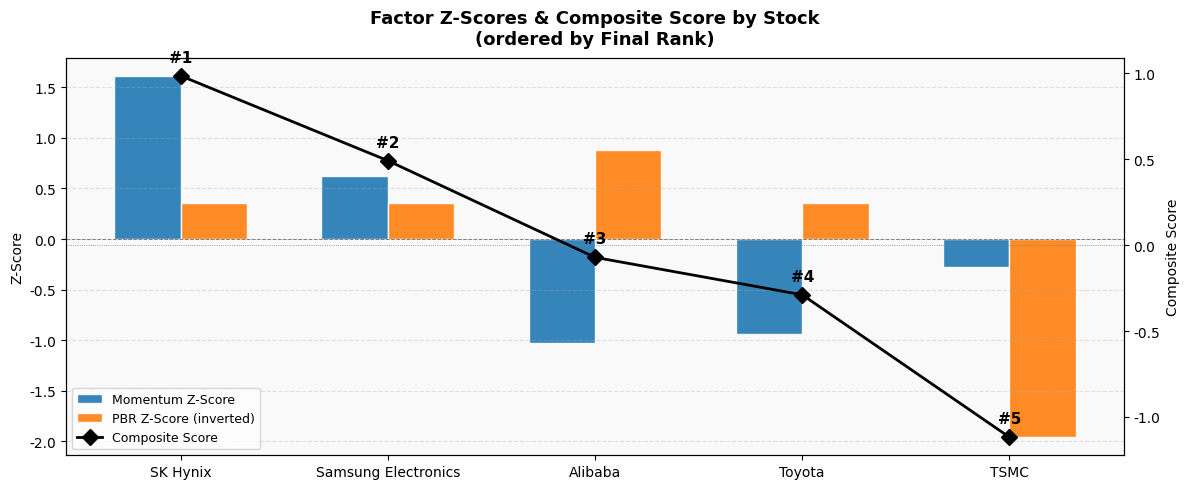

Saved: factor_zscores.png


In [13]:
# ── 9. Z-Score Radar / Grouped Bar — Factor Scores per Stock ───────────
# Grouped bars: Momentum Z (blue) vs PBR Z-inverted (orange)
# Ordered by final composite score

names_ordered = results.index.tolist()
x = np.arange(len(names_ordered))
w = 0.32

fig, ax = plt.subplots(figsize=(12, 5))

b1 = ax.bar(x - w/2, results.loc[names_ordered, 'Momentum Z'],
            width=w, label='Momentum Z-Score', color='#1f77b4',
            edgecolor='white', alpha=0.9)
b2 = ax.bar(x + w/2, results.loc[names_ordered, 'PBR Z (inv)'],
            width=w, label='PBR Z-Score (inverted)', color='#ff7f0e',
            edgecolor='white', alpha=0.9)

# Composite score overlay (line)
ax2 = ax.twinx()
ax2.plot(x, results.loc[names_ordered, 'Composite Score'],
         color='black', marker='D', linewidth=2, markersize=8,
         label='Composite Score', zorder=5)
ax2.set_ylabel('Composite Score', fontsize=10)
ax2.axhline(0, color='grey', linewidth=0.6, linestyle=':')

# Rank badges
for i, name in enumerate(names_ordered):
    rank_val = int(results.loc[name, 'Final Rank'])
    comp_val = results.loc[name, 'Composite Score']
    ax2.annotate(f'#{rank_val}',
                 xy=(i, comp_val), xytext=(0, 10),
                 textcoords='offset points', ha='center',
                 fontsize=11, fontweight='bold', color='black')

ax.axhline(0, color='grey', linewidth=0.7, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(names_ordered, fontsize=10)
ax.set_ylabel('Z-Score', fontsize=10)
ax.set_title('Factor Z-Scores & Composite Score by Stock\n(ordered by Final Rank)',
             fontsize=13, fontweight='bold', pad=10)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.set_facecolor('#f9f9f9')

# Combined legend
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, fontsize=9, loc='lower left')

fig.tight_layout()
plt.savefig('factor_zscores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: factor_zscores.png')

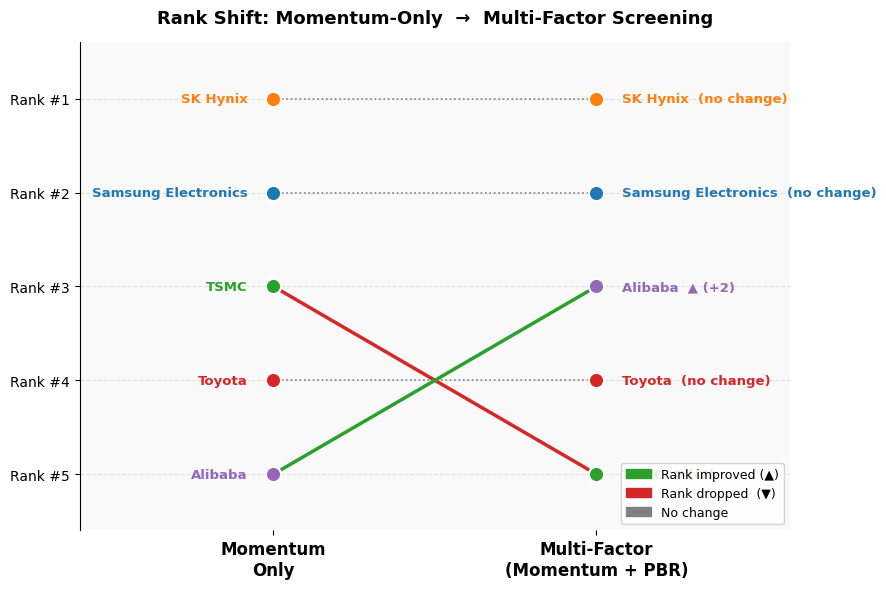

Saved: rank_shift.png


In [14]:
# ── 10. Rank Shift Chart — Momentum-only vs Multi-Factor ───────────────
# Slope chart (bump chart) showing which stocks moved up/down

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_xlim(-0.6, 1.6)
ax.set_ylim(5.6, 0.4)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Momentum\nOnly', 'Multi-Factor\n(Momentum + PBR)'],
                   fontsize=12, fontweight='bold')
ax.set_yticks(range(1, 6))
ax.set_yticklabels([f'Rank #{i}' for i in range(1, 6)], fontsize=10)
ax.set_title('Rank Shift: Momentum-Only  →  Multi-Factor Screening',
             fontsize=13, fontweight='bold', pad=14)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_facecolor('#f9f9f9')
ax.spines[['top', 'right', 'bottom']].set_visible(False)

for i, name in enumerate(NAMES):
    r_mom   = int(rank_cmp.loc[name, 'Momentum Rank'])
    r_final = int(rank_cmp.loc[name, 'Final Rank'])
    shift   = r_mom - r_final   # positive = improved

    lc = C_POS if shift > 0 else (C_NEG if shift < 0 else 'grey')
    lw = 2.5 if shift != 0 else 1.2
    ls = '-' if shift != 0 else ':'

    ax.plot([0, 1], [r_mom, r_final], color=lc, lw=lw, ls=ls, zorder=2)
    ax.scatter([0, 1], [r_mom, r_final],
               color=COLORS[i], s=120, zorder=3, edgecolors='white', lw=1.5)

    # Left labels
    ax.text(-0.08, r_mom, name, ha='right', va='center',
            fontsize=9.5, color=COLORS[i], fontweight='bold')
    # Right labels with shift arrow
    arrow = '  ▲' if shift > 0 else ('  ▼' if shift < 0 else '  –')
    label_color = C_POS if shift > 0 else (C_NEG if shift < 0 else 'grey')
    ax.text(1.08, r_final,
            f'{name}{arrow} ({shift:+d})' if shift != 0 else f'{name}  (no change)',
            ha='left', va='center', fontsize=9.5,
            color=COLORS[i], fontweight='bold')

# Legend patches
leg = [
    mpatches.Patch(color=C_POS, label='Rank improved (▲)'),
    mpatches.Patch(color=C_NEG, label='Rank dropped  (▼)'),
    mpatches.Patch(color='grey', label='No change'),
]
ax.legend(handles=leg, fontsize=9, loc='lower right',
          framealpha=0.85, edgecolor='#cccccc')

fig.tight_layout()
plt.savefig('rank_shift.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: rank_shift.png')

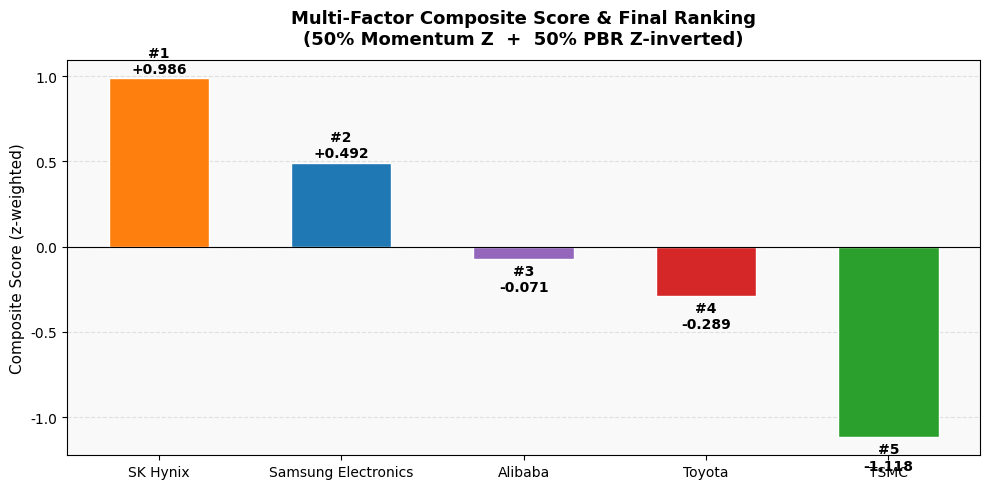

Saved: composite_score.png


In [15]:
# ── 11. Composite Score Bar Chart (Final Ranking) ──────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

names_fin = results.index.tolist()
scores    = results['Composite Score'].values
cols_fin  = [COLORS[NAMES.index(n)] for n in names_fin]

bars = ax.bar(names_fin, scores, color=cols_fin, edgecolor='white',
              width=0.55, zorder=2)

for bar, val, name in zip(bars, scores, names_fin):
    rank_val = int(results.loc[name, 'Final Rank'])
    y_txt    = val + 0.015 if val >= 0 else val - 0.03
    va_txt   = 'bottom' if val >= 0 else 'top'
    ax.text(bar.get_x() + bar.get_width() / 2, y_txt,
            f'#{rank_val}\n{val:+.3f}',
            ha='center', va=va_txt, fontsize=10, fontweight='bold')

ax.axhline(0, color='black', lw=0.8)
ax.set_title('Multi-Factor Composite Score & Final Ranking\n'
             '(50% Momentum Z  +  50% PBR Z-inverted)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Composite Score (z-weighted)', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.set_facecolor('#f9f9f9')
fig.tight_layout()
plt.savefig('composite_score.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: composite_score.png')

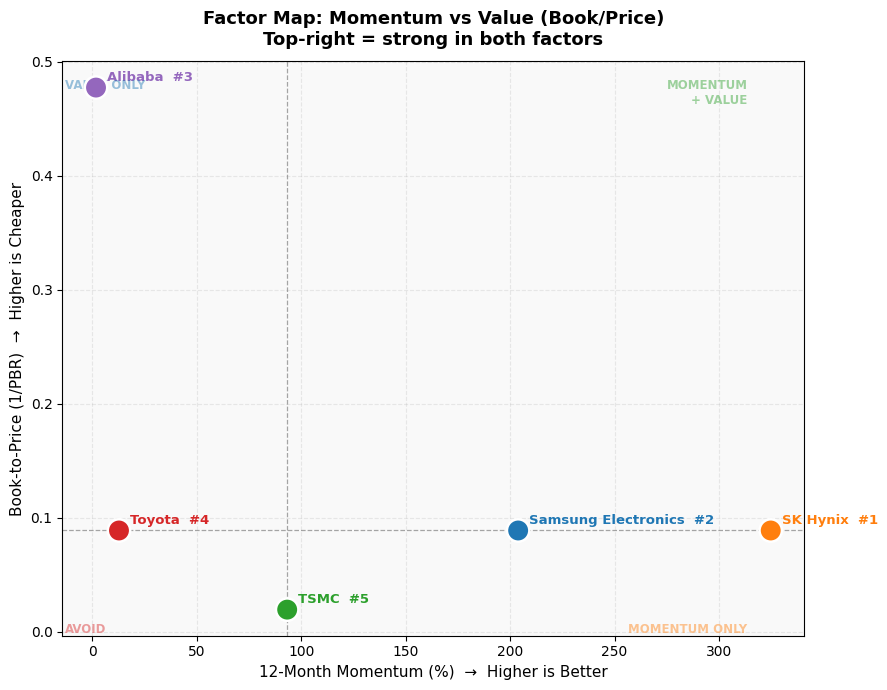

Saved: factor_map.png


In [16]:
# ── 12. Momentum vs PBR Scatter — Factor Map ───────────────────────────
# Quadrant map: X = Momentum (higher=better), Y = 1/PBR = Book/Price (higher=cheaper)
# Best stocks → top-right quadrant

bp_ratio = 1 / pbr   # Book-to-Price (higher = cheaper = better for value)

fig, ax = plt.subplots(figsize=(9, 7))

sc = ax.scatter(momentum, bp_ratio,
                c=[COLORS[NAMES.index(n)] for n in momentum.index],
                s=260, edgecolors='white', linewidths=1.8, zorder=4)

for i, name in enumerate(momentum.index):
    rank_val = int(results.loc[name, 'Final Rank'])
    ax.annotate(f'{name}  #{rank_val}',
                xy=(momentum[name], bp_ratio[name]),
                xytext=(8, 5), textcoords='offset points',
                fontsize=9.5, color=COLORS[NAMES.index(name)], fontweight='bold')

# Quadrant dividers at medians
med_x = momentum.median()
med_y = bp_ratio.median()
ax.axvline(med_x, color='grey', lw=0.9, ls='--', alpha=0.7)
ax.axhline(med_y, color='grey', lw=0.9, ls='--', alpha=0.7)

# Quadrant labels
xlim, ylim = ax.get_xlim(), ax.get_ylim()
kw = dict(fontsize=8.5, alpha=0.45, fontweight='bold')
ax.text(xlim[1] * 0.92, ylim[1] * 0.97, 'MOMENTUM\n+ VALUE',  ha='right', va='top',    color=C_POS, **kw)
ax.text(xlim[0] * 0.92, ylim[1] * 0.97, 'VALUE ONLY',          ha='left',  va='top',    color='#1f77b4', **kw)
ax.text(xlim[1] * 0.92, ylim[0] * 0.97, 'MOMENTUM ONLY',       ha='right', va='bottom', color='#ff7f0e', **kw)
ax.text(xlim[0] * 0.92, ylim[0] * 0.97, 'AVOID',               ha='left',  va='bottom', color=C_NEG, **kw)

ax.set_title('Factor Map: Momentum vs Value (Book/Price)\n'
             'Top-right = strong in both factors',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('12-Month Momentum (%)  →  Higher is Better', fontsize=11)
ax.set_ylabel('Book-to-Price (1/PBR)  →  Higher is Cheaper', fontsize=11)
ax.grid(linestyle='--', alpha=0.25)
ax.set_facecolor('#f9f9f9')
fig.tight_layout()
plt.savefig('factor_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: factor_map.png')

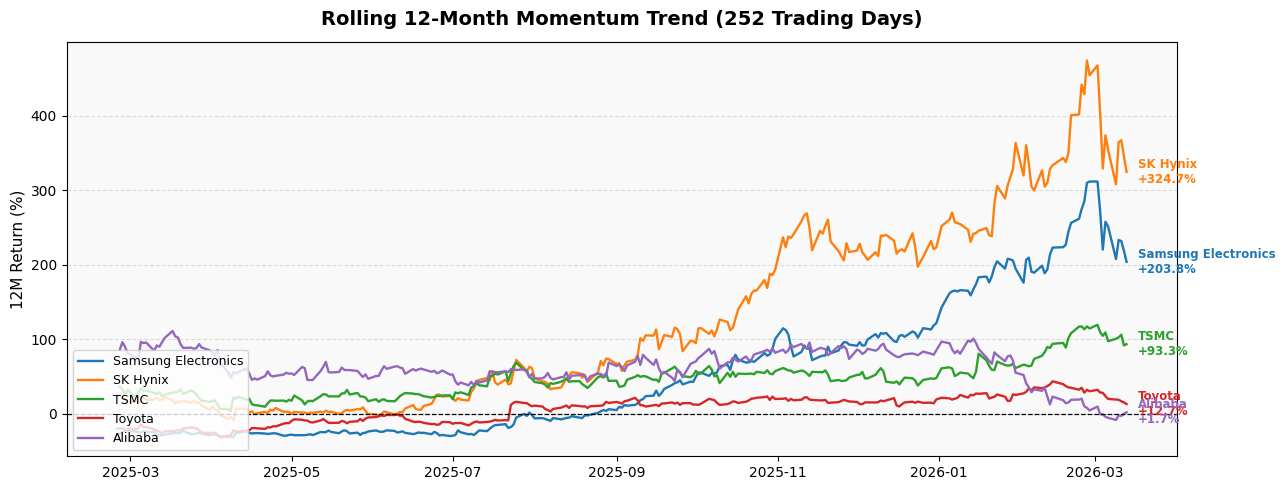

Saved: rolling_momentum.png


In [17]:
# ── 13. Rolling 12-month momentum (historical context) ─────────────────
rolling_mom = close_filled.pct_change(LOOKBACK) * 100
rolling_mom.dropna(how='all', inplace=True)

fig, ax = plt.subplots(figsize=(13, 5))
for i, col in enumerate(rolling_mom.columns):
    ax.plot(rolling_mom.index, rolling_mom[col],
            label=col, color=COLORS[i], linewidth=1.7)
ax.axhline(0, color='black', lw=0.9, ls='--')
for i, col in enumerate(rolling_mom.columns):
    last = rolling_mom[col].dropna().iloc[-1]
    ax.annotate(f'{col}\n{last:+.1f}%',
                xy=(rolling_mom.index[-1], last),
                xytext=(8, 0), textcoords='offset points',
                color=COLORS[i], fontsize=8.5, fontweight='bold', va='center')
ax.set_title('Rolling 12-Month Momentum Trend (252 Trading Days)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('12M Return (%)', fontsize=11)
ax.legend(fontsize=9, loc='lower left')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_facecolor('#f9f9f9')
fig.tight_layout()
plt.savefig('rolling_momentum.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: rolling_momentum.png')

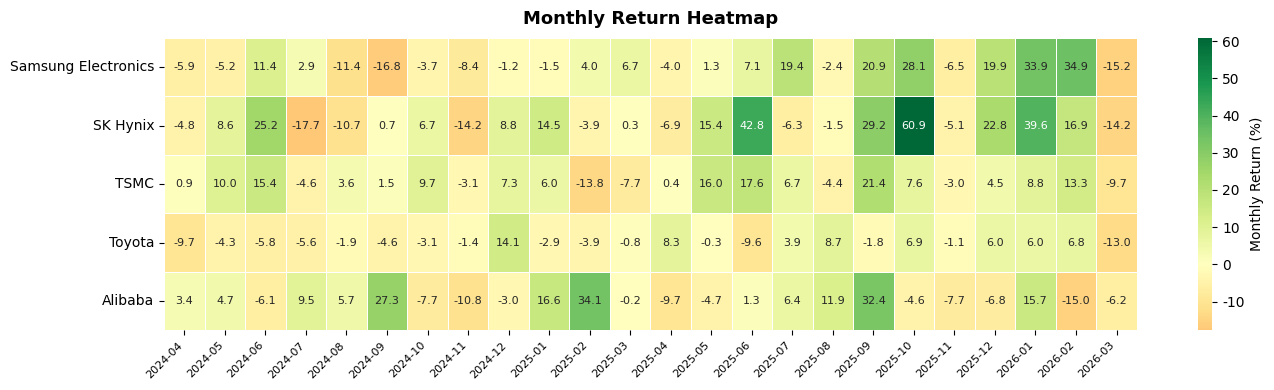

Saved: heatmap_monthly.png


In [18]:
# ── 14. Monthly return heatmap ──────────────────────────────────────────
monthly = close_filled.resample('ME').last().pct_change() * 100
monthly.dropna(how='all', inplace=True)
monthly.index = monthly.index.strftime('%Y-%m')

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(monthly.T, ax=ax, cmap='RdYlGn', center=0,
            annot=True, fmt='.1f', linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Monthly Return (%)'}, annot_kws={'size': 8})
ax.set_title('Monthly Return Heatmap', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=8)
fig.tight_layout()
plt.savefig('heatmap_monthly.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: heatmap_monthly.png')

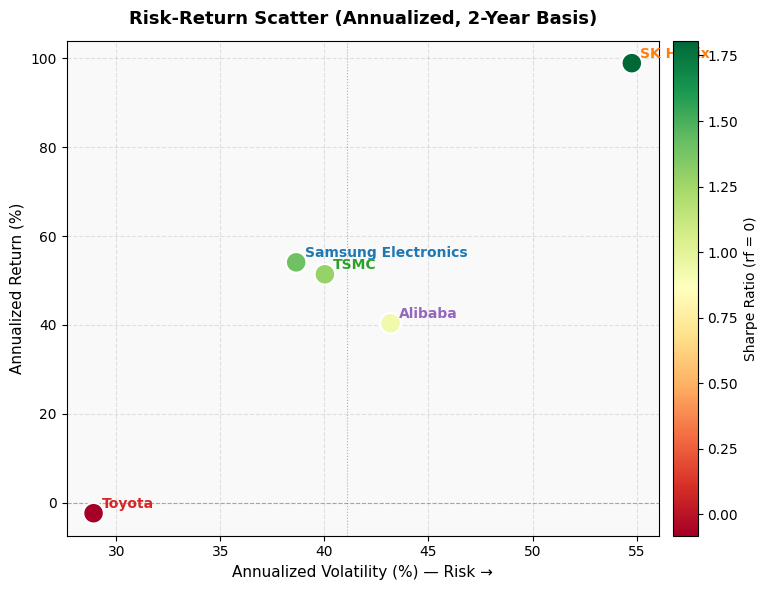

Saved: risk_return.png


In [19]:
# ── 15. Risk-Return Scatter ─────────────────────────────────────────────
daily_ret = close_filled.pct_change().dropna()
ann_ret   = daily_ret.mean() * 252 * 100
ann_vol   = daily_ret.std()  * np.sqrt(252) * 100
sharpe    = ann_ret / ann_vol

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(ann_vol, ann_ret, c=sharpe, cmap='RdYlGn',
                     s=220, edgecolors='white', linewidths=1.5, zorder=3)
plt.colorbar(scatter, ax=ax, label='Sharpe Ratio (rf = 0)', pad=0.02)
for i, name in enumerate(ann_ret.index):
    ax.annotate(name, xy=(ann_vol[name], ann_ret[name]),
                xytext=(6, 4), textcoords='offset points',
                fontsize=10, fontweight='bold', color=COLORS[i])
ax.axhline(0, color='grey', ls='--', lw=0.8, alpha=0.6)
ax.axvline(ann_vol.mean(), color='grey', ls=':', lw=0.8, alpha=0.6)
ax.set_title('Risk-Return Scatter (Annualized, 2-Year Basis)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Annualized Volatility (%) — Risk →', fontsize=11)
ax.set_ylabel('Annualized Return (%)', fontsize=11)
ax.grid(linestyle='--', alpha=0.35)
ax.set_facecolor('#f9f9f9')
fig.tight_layout()
plt.savefig('risk_return.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: risk_return.png')

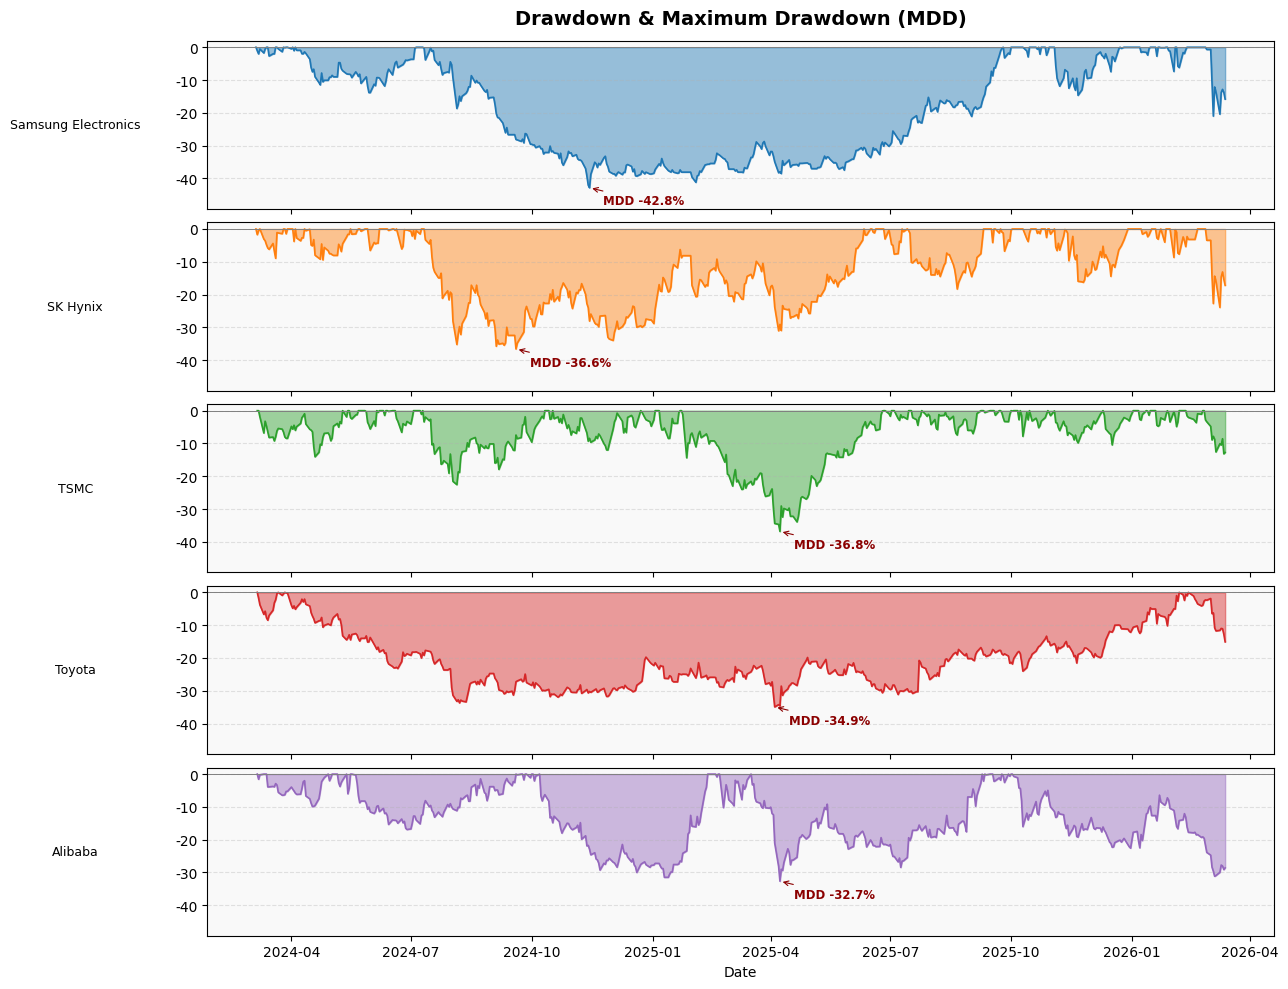

Saved: drawdown.png


In [20]:
# ── 16. Drawdown & MDD ──────────────────────────────────────────────────
def drawdown_series(prices):
    return (prices / prices.cummax() - 1) * 100

dd  = close_filled.apply(drawdown_series)
mdd = dd.min()

fig, axes = plt.subplots(len(TICKERS), 1, figsize=(13, 10), sharex=True)
for i, (col, ax) in enumerate(zip(dd.columns, axes)):
    ax.fill_between(dd.index, dd[col], 0, color=COLORS[i], alpha=0.45)
    ax.plot(dd.index, dd[col], color=COLORS[i], linewidth=1.2)
    ax.axhline(0, color='grey', linewidth=0.7)
    mdd_idx = dd[col].idxmin()
    ax.annotate(f'MDD {mdd[col]:.1f}%', xy=(mdd_idx, mdd[col]),
                xytext=(10, -12), textcoords='offset points',
                fontsize=8.5, color='darkred', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='darkred', lw=0.8))
    ax.set_ylabel(col, fontsize=9, rotation=0, labelpad=72, va='center')
    ax.set_ylim(min(mdd.min() * 1.15, -5), 2)
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.set_facecolor('#f9f9f9')
axes[0].set_title('Drawdown & Maximum Drawdown (MDD)',
                   fontsize=14, fontweight='bold', pad=12)
axes[-1].set_xlabel('Date', fontsize=10)
fig.tight_layout(h_pad=0.6)
plt.savefig('drawdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: drawdown.png')

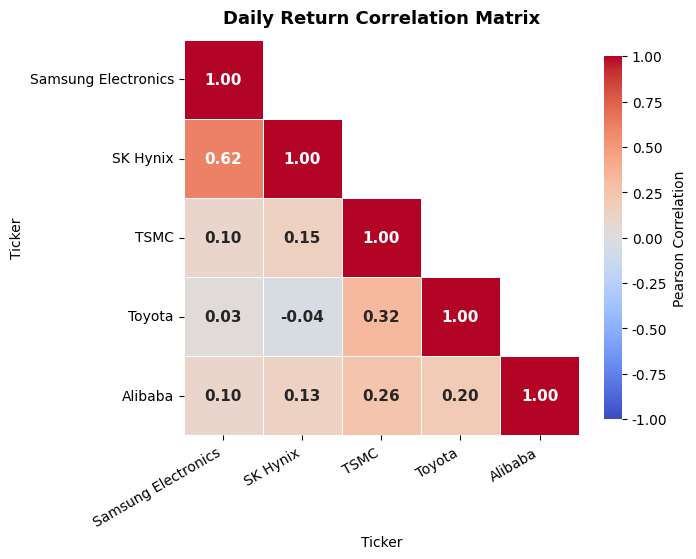

Saved: correlation.png


In [21]:
# ── 17. Correlation Heatmap ─────────────────────────────────────────────
corr = daily_ret.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, ax=ax, mask=mask, cmap='coolwarm', vmin=-1, vmax=1, center=0,
            annot=True, fmt='.2f', linewidths=0.5, linecolor='white', square=True,
            cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8},
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Daily Return Correlation Matrix',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
fig.tight_layout()
plt.savefig('correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: correlation.png')

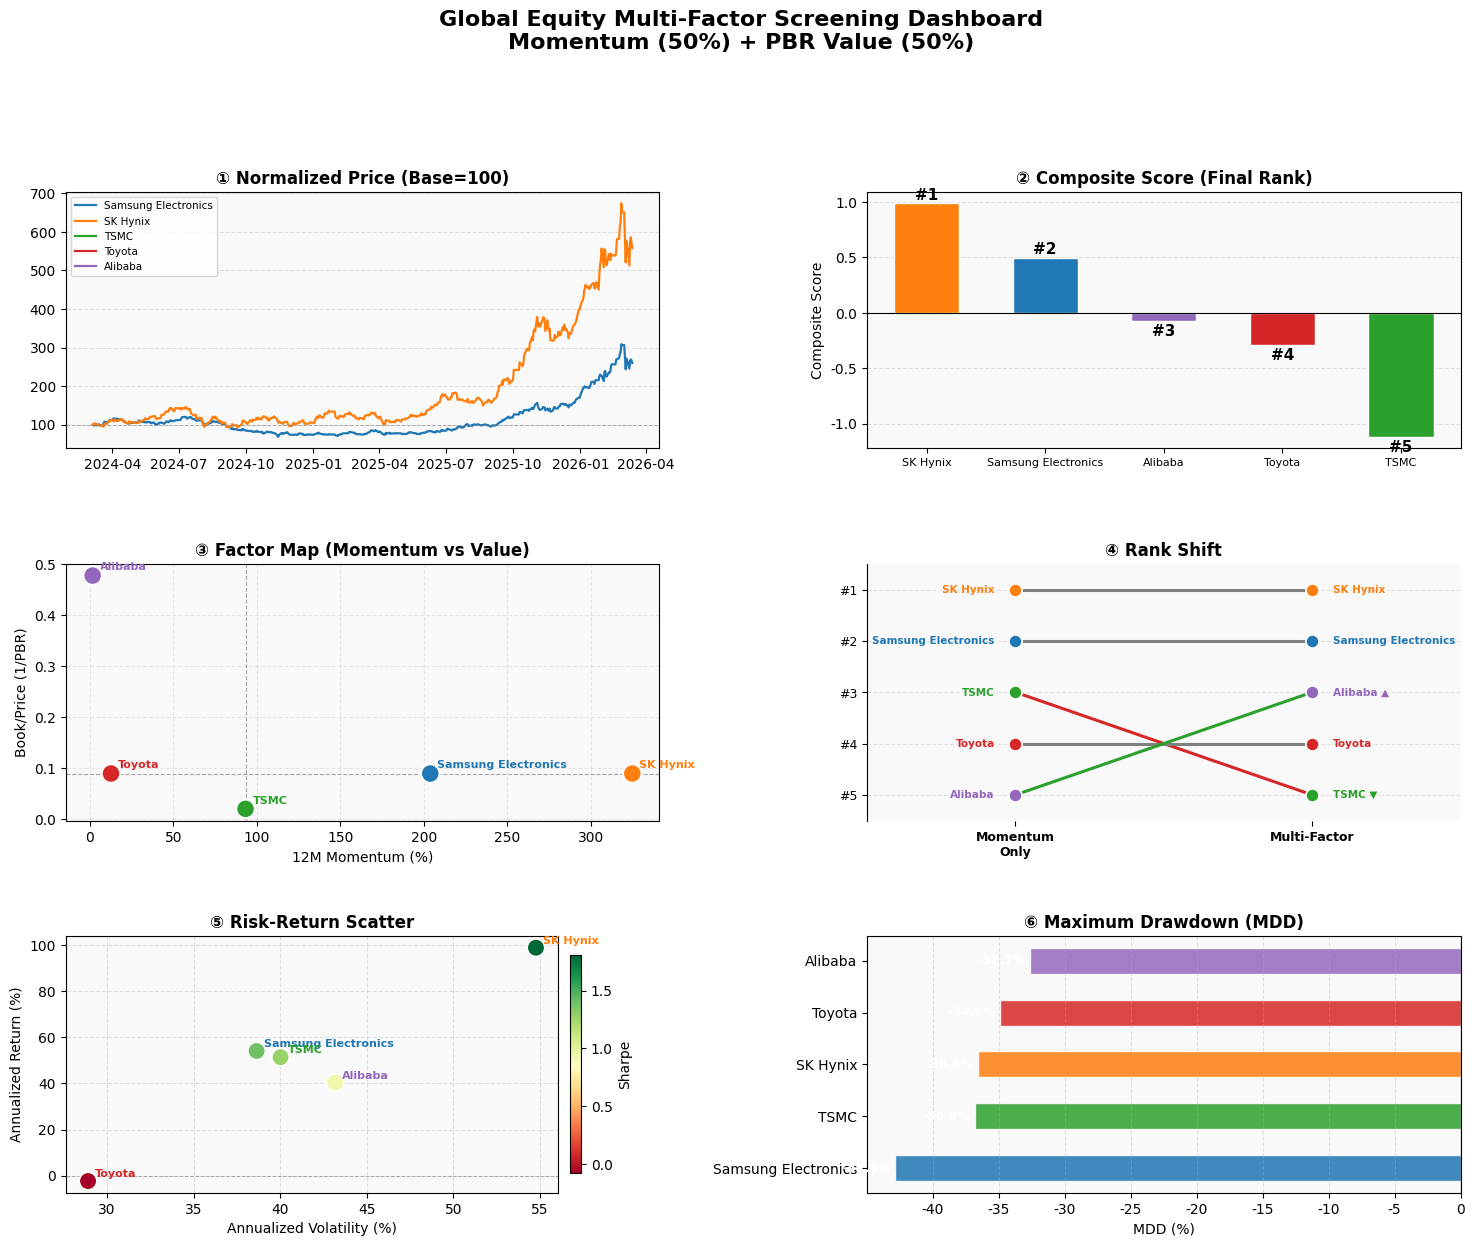

Saved: dashboard_multifactor.png


In [22]:
# ── 18. Multi-Factor Dashboard (3×2) ───────────────────────────────────
# ① Normalized price   ② Composite score ranking
# ③ Factor map         ④ Rank shift (slope chart)
# ⑤ Risk-return        ⑥ MDD bar

fig = plt.figure(figsize=(18, 13))
fig.suptitle('Global Equity Multi-Factor Screening Dashboard\n'
             'Momentum (50%) + PBR Value (50%)',
             fontsize=16, fontweight='bold', y=1.02)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ─ ① Normalized price ───────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
norm = close_filled.div(close_filled.iloc[0]) * 100
for i, col in enumerate(norm.columns):
    ax1.plot(norm.index, norm[col], color=COLORS[i], label=col, lw=1.6)
ax1.axhline(100, color='grey', ls='--', lw=0.7, alpha=0.6)
ax1.set_title('① Normalized Price (Base=100)', fontweight='bold')
ax1.legend(fontsize=7.5)
ax1.grid(axis='y', ls='--', alpha=0.35)
ax1.set_facecolor('#f9f9f9')

# ─ ② Composite score bar ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
nf   = results.index.tolist()
sc_  = results['Composite Score'].values
cf_  = [COLORS[NAMES.index(n)] for n in nf]
b_   = ax2.bar(nf, sc_, color=cf_, edgecolor='white', width=0.55, zorder=2)
for bar, val, name in zip(b_, sc_, nf):
    rv  = int(results.loc[name, 'Final Rank'])
    y_  = val + 0.01 if val >= 0 else val - 0.025
    va_ = 'bottom' if val >= 0 else 'top'
    ax2.text(bar.get_x() + bar.get_width() / 2, y_,
             f'#{rv}', ha='center', va=va_, fontsize=11, fontweight='bold')
ax2.axhline(0, color='black', lw=0.8)
ax2.set_title('② Composite Score (Final Rank)', fontweight='bold')
ax2.set_ylabel('Composite Score')
ax2.grid(axis='y', ls='--', alpha=0.35)
ax2.set_facecolor('#f9f9f9')
ax2.tick_params(axis='x', labelsize=8)

# ─ ③ Factor map ─────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(momentum, bp_ratio,
            c=[COLORS[NAMES.index(n)] for n in momentum.index],
            s=180, edgecolors='white', lw=1.5, zorder=4)
for i, name in enumerate(momentum.index):
    ax3.annotate(name, xy=(momentum[name], bp_ratio[name]),
                 xytext=(5, 4), textcoords='offset points',
                 fontsize=8, color=COLORS[NAMES.index(name)], fontweight='bold')
ax3.axvline(momentum.median(), color='grey', lw=0.8, ls='--', alpha=0.7)
ax3.axhline(bp_ratio.median(), color='grey', lw=0.8, ls='--', alpha=0.7)
ax3.set_title('③ Factor Map (Momentum vs Value)', fontweight='bold')
ax3.set_xlabel('12M Momentum (%)')
ax3.set_ylabel('Book/Price (1/PBR)')
ax3.grid(ls='--', alpha=0.25)
ax3.set_facecolor('#f9f9f9')

# ─ ④ Rank shift ─────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_xlim(-0.5, 1.5)
ax4.set_ylim(5.5, 0.5)
ax4.set_xticks([0, 1])
ax4.set_xticklabels(['Momentum\nOnly', 'Multi-Factor'], fontsize=9, fontweight='bold')
ax4.set_yticks(range(1, 6))
ax4.set_yticklabels([f'#{i}' for i in range(1, 6)], fontsize=9)
ax4.set_title('④ Rank Shift', fontweight='bold')
ax4.yaxis.grid(True, ls='--', alpha=0.3)
ax4.set_facecolor('#f9f9f9')
ax4.spines[['top', 'right', 'bottom']].set_visible(False)
for name in NAMES:
    rm = int(rank_cmp.loc[name, 'Momentum Rank'])
    rf = int(rank_cmp.loc[name, 'Final Rank'])
    sh = rm - rf
    lc = C_POS if sh > 0 else (C_NEG if sh < 0 else 'grey')
    ax4.plot([0, 1], [rm, rf], color=lc, lw=2.2, zorder=2)
    ax4.scatter([0, 1], [rm, rf],
                color=COLORS[NAMES.index(name)], s=90, zorder=3,
                edgecolors='white', lw=1.2)
    ax4.text(-0.07, rm, name, ha='right', va='center',
             fontsize=7.5, color=COLORS[NAMES.index(name)], fontweight='bold')
    arr = ' ▲' if sh > 0 else (' ▼' if sh < 0 else '')
    ax4.text(1.07, rf, f'{name}{arr}', ha='left', va='center',
             fontsize=7.5, color=COLORS[NAMES.index(name)], fontweight='bold')

# ─ ⑤ Risk-return ────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
sc5 = ax5.scatter(ann_vol, ann_ret, c=sharpe, cmap='RdYlGn',
                   s=160, edgecolors='white', lw=1.2, zorder=3)
plt.colorbar(sc5, ax=ax5, label='Sharpe', pad=0.02, shrink=0.85)
for i, name in enumerate(ann_ret.index):
    ax5.annotate(name, xy=(ann_vol[name], ann_ret[name]),
                 xytext=(5, 3), textcoords='offset points',
                 fontsize=8, color=COLORS[i], fontweight='bold')
ax5.axhline(0, color='grey', ls='--', lw=0.7, alpha=0.6)
ax5.set_title('⑤ Risk-Return Scatter', fontweight='bold')
ax5.set_xlabel('Annualized Volatility (%)')
ax5.set_ylabel('Annualized Return (%)')
ax5.grid(ls='--', alpha=0.35)
ax5.set_facecolor('#f9f9f9')

# ─ ⑥ MDD bar ────────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
mdd_s  = mdd.sort_values()
mdd_c  = [COLORS[list(dd.columns).index(n)] for n in mdd_s.index]
b6     = ax6.barh(mdd_s.index, mdd_s.values,
                   color=mdd_c, edgecolor='white', height=0.5, alpha=0.85)
for bar, val in zip(b6, mdd_s.values):
    ax6.text(val - 0.3, bar.get_y() + bar.get_height() / 2,
             f'{val:.1f}%', va='center', ha='right',
             fontsize=9, fontweight='bold', color='white')
ax6.axvline(0, color='black', lw=0.8)
ax6.set_title('⑥ Maximum Drawdown (MDD)', fontweight='bold')
ax6.set_xlabel('MDD (%)')
ax6.grid(axis='x', ls='--', alpha=0.35)
ax6.set_facecolor('#f9f9f9')

plt.savefig('dashboard_multifactor.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dashboard_multifactor.png')

In [23]:
# ── 19. Final Summary ───────────────────────────────────────────────────
medals = ['🥇', '🥈', '🥉', ' 4th', ' 5th']
shifts = {name: int(rank_cmp.loc[name, 'Momentum Rank']) - int(rank_cmp.loc[name, 'Final Rank'])
          for name in NAMES}

print('=' * 72)
print('  📊  Multi-Factor Screening — Final Results  (Momentum 50% + PBR 50%)')
print('=' * 72)
print(f"  {'Stock':<24} {'Composite':>10} {'Mom Rank':>10} {'PBR Rank':>10} {'Final':>8} {'Shift':>8}")
print('  ' + '-' * 68)
for _, row in results.iterrows():
    medal = medals[int(row['Final Rank']) - 1]
    sh    = shifts[_]
    arrow = f'+{sh} ▲' if sh > 0 else (f'{sh} ▼' if sh < 0 else ' – ')
    print(f"  {medal} {_:<22} {row['Composite Score']:>+10.3f} "
          f"{int(row['Momentum Rank']):>10} {int(row['PBR Rank']):>10} "
          f"#{int(row['Final Rank']):<7} {arrow}")
print('=' * 72)
print(f"  As-of date   : {close_filled.index[-1].date()}")
print(f"  Compare date : {close_filled.index[-1 - LOOKBACK].date()}")
print(f"  Weights      : Momentum {W_MOM:.0%}  |  PBR {W_PBR:.0%}")
print(f"  Score method : Cross-sectional z-score; PBR negated before weighting")
print('=' * 72)

  📊  Multi-Factor Screening — Final Results  (Momentum 50% + PBR 50%)
  Stock                     Composite   Mom Rank   PBR Rank    Final    Shift
  --------------------------------------------------------------------
  🥇 SK Hynix                   +0.986          1          3 #1        – 
  🥈 Samsung Electronics        +0.492          2          3 #2        – 
  🥉 Alibaba                    -0.071          5          1 #3       +2 ▲
   4th Toyota                     -0.289          4          3 #4        – 
   5th TSMC                       -1.118          3          5 #5       -2 ▼
  As-of date   : 2026-03-13
  Compare date : 2025-03-21
  Weights      : Momentum 50%  |  PBR 50%
  Score method : Cross-sectional z-score; PBR negated before weighting


## 분석의 한계 및 향후 개선 방향

### 한계
1. **샘플 부족**: 5개 종목만 분석하여 통계적 유의성이 낮음
2. **팩터 단순화**: 모멘텀과 PBR 외 ROE, 영업이익률 등 
   수익성 지표 미반영
3. **동일 가중**: 모멘텀 50% + PBR 50% 고정 비율 사용. 
   시장 국면에 따라 최적 비율은 달라질 수 있음
4. **거래비용 미반영**: 실제 투자 시 수익률과 차이 존재

### 향후 개선 방향
- 분석 대상 종목 확대 (아시아 주요 50개 종목 이상)
- Earnings Surprise(실적 서프라이즈) 팩터 추가로 
  3-factor 모델로 확장 예정